In [1]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

import pandas as pd
import duckdb
from pathlib import Path
from config import RESEARCH_ROOT, NSE_DB_PATH

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import numpy as np
from scipy import stats

In [ ]:
RESEARCH_DB_PATH = RESEARCH_ROOT / "research.db"
con = duckdb.connect(RESEARCH_DB_PATH)

In [3]:
df = con.execute("SELECT * FROM daily_features ORDER BY trade_date").df()
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.set_index('trade_date')

print(df.shape)
print(df.index.min(), df.index.max())

(2617, 49)
2016-01-01 00:00:00 2026-07-27 00:00:00


In [4]:
# quick look at missingness — important since you have a long history (2016+)
# and many of these fields (FII/DII stats, HMM state) probably don't exist for the full range
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]

hmm_state                  0.103554
cost_of_carry              0.048529
fwd_ret_20d                0.007642
max_pain_dist_chg_5d       0.002293
basis_chg_5d               0.002293
pcr_chg_5d                 0.002293
fii_fut_net_chg_5d         0.002293
vix_chg_5d                 0.001911
fwd_ret_5d                 0.001911
fii_stk_fut_net_pct        0.000764
client_stk_fut_net_pct     0.000764
fii_opt_skew_pct           0.000764
pro_fut_net_pct            0.000764
dii_opt_skew_pct           0.000764
pro_opt_skew_pct           0.000764
fii_client_divergence      0.000764
client_opt_skew_pct        0.000764
dii_fut_net_pct            0.000764
fii_stats_fut_net_pct      0.000382
fii_stats_oi_net_cr        0.000382
fii_vol_opt_skew_pct       0.000382
fii_net_flow_cr            0.000382
fii_pe_net_pct             0.000382
client_vol_opt_skew_pct    0.000382
fii_vol_fut_net_pct        0.000382
client_vol_fut_net_pct     0.000382
pcr                        0.000382
max_pain_dist_pct          0

In [5]:
df_work = df.drop(columns=['hmm_state', 'split'])

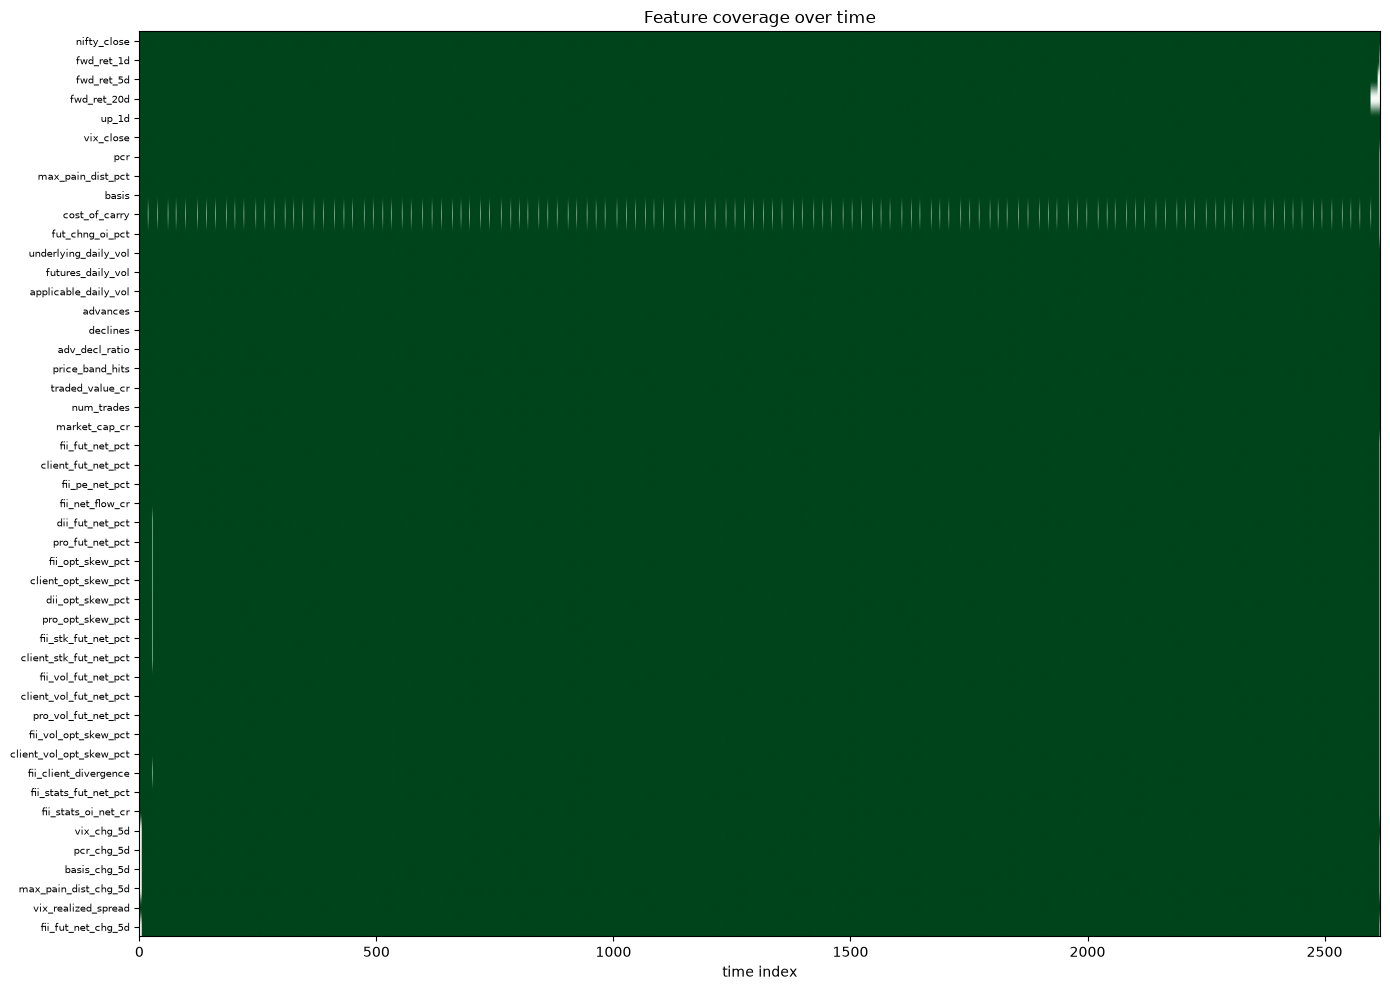

In [6]:
# quick visual: which features have data at which point in time (helps spot regime changes in data collection)
fig, ax = plt.subplots(figsize=(14, 10))
coverage = df_work.notna().astype(int)
ax.imshow(coverage.T, aspect='auto', cmap='Greens', 
          extent=[0, len(df_work), 0, len(df_work.columns)])
ax.set_yticks(np.arange(len(df_work.columns)) + 0.5)
ax.set_yticklabels(df_work.columns[::-1], fontsize=7)
ax.set_xlabel('time index')
ax.set_title('Feature coverage over time')
plt.tight_layout()
plt.show()

In [7]:
# also just print first valid date per column, sorted
first_valid = df_work.apply(lambda s: s.first_valid_index()).sort_values(ascending=False)
first_valid

fii_fut_net_chg_5d        2016-01-08
max_pain_dist_chg_5d      2016-01-08
basis_chg_5d              2016-01-08
pcr_chg_5d                2016-01-08
vix_chg_5d                2016-01-08
fii_vol_fut_net_pct       2016-01-01
pro_fut_net_pct           2016-01-01
fii_opt_skew_pct          2016-01-01
client_opt_skew_pct       2016-01-01
dii_opt_skew_pct          2016-01-01
pro_opt_skew_pct          2016-01-01
fii_stk_fut_net_pct       2016-01-01
client_stk_fut_net_pct    2016-01-01
fii_vol_opt_skew_pct      2016-01-01
client_vol_fut_net_pct    2016-01-01
pro_vol_fut_net_pct       2016-01-01
fii_net_flow_cr           2016-01-01
client_vol_opt_skew_pct   2016-01-01
fii_client_divergence     2016-01-01
fii_stats_fut_net_pct     2016-01-01
fii_stats_oi_net_cr       2016-01-01
vix_realized_spread       2016-01-01
dii_fut_net_pct           2016-01-01
nifty_close               2016-01-01
fwd_ret_1d                2016-01-01
underlying_daily_vol      2016-01-01
fwd_ret_5d                2016-01-01
f

In [8]:
for col in df_work.columns:
    missing_dates = df_work[df_work[col].isna()].index
    if len(missing_dates) > 0:
        print(f"\n{col} ({len(missing_dates)} missing):")
        print(list(missing_dates.date))


fwd_ret_1d (1 missing):
[datetime.date(2026, 7, 27)]

fwd_ret_5d (5 missing):
[datetime.date(2026, 7, 21), datetime.date(2026, 7, 22), datetime.date(2026, 7, 23), datetime.date(2026, 7, 24), datetime.date(2026, 7, 27)]

fwd_ret_20d (20 missing):
[datetime.date(2026, 6, 30), datetime.date(2026, 7, 1), datetime.date(2026, 7, 2), datetime.date(2026, 7, 3), datetime.date(2026, 7, 6), datetime.date(2026, 7, 7), datetime.date(2026, 7, 8), datetime.date(2026, 7, 9), datetime.date(2026, 7, 10), datetime.date(2026, 7, 13), datetime.date(2026, 7, 14), datetime.date(2026, 7, 15), datetime.date(2026, 7, 16), datetime.date(2026, 7, 17), datetime.date(2026, 7, 20), datetime.date(2026, 7, 21), datetime.date(2026, 7, 22), datetime.date(2026, 7, 23), datetime.date(2026, 7, 24), datetime.date(2026, 7, 27)]

pcr (1 missing):
[datetime.date(2026, 7, 27)]

max_pain_dist_pct (1 missing):
[datetime.date(2026, 7, 27)]

basis (1 missing):
[datetime.date(2026, 7, 27)]

cost_of_carry (127 missing):
[datetime.da

In [9]:
df_work = df_work.copy()

# forward-fill the single genuinely missing OI date (2016-02-10)
oi_cols = ['dii_fut_net_pct', 'pro_fut_net_pct', 'fii_opt_skew_pct', 'client_opt_skew_pct',
           'dii_opt_skew_pct', 'pro_opt_skew_pct', 'fii_stk_fut_net_pct', 'client_stk_fut_net_pct',
           'fii_client_divergence']
df_work[oi_cols] = df_work[oi_cols].ffill(limit=1)

# drop today's partial row (no forward returns / fresh data yet)
df_work = df_work[df_work.index < pd.Timestamp('2026-07-27')]

print(df_work.shape)
print(df_work.isna().sum()[df_work.isna().sum() > 0])

(2616, 47)
fwd_ret_5d                4
fwd_ret_20d              19
cost_of_carry           126
vix_chg_5d                5
pcr_chg_5d                5
basis_chg_5d              5
max_pain_dist_chg_5d      5
fii_fut_net_chg_5d        5
dtype: int64


In [10]:
feature_groups = {
    'price_vol': ['nifty_close', 'vix_close', 'underlying_daily_vol', 'futures_daily_vol', 'applicable_daily_vol'],
    'options_derived': ['pcr', 'max_pain_dist_pct', 'basis', 'cost_of_carry', 'fut_chng_oi_pct'],
    'breadth': ['advances', 'declines', 'adv_decl_ratio', 'price_band_hits', 'traded_value_cr', 'num_trades', 'market_cap_cr'],
    'fii_dii_positioning': ['fii_fut_net_pct', 'client_fut_net_pct', 'fii_pe_net_pct', 'fii_net_flow_cr',
                            'dii_fut_net_pct', 'pro_fut_net_pct', 'fii_stk_fut_net_pct', 'client_stk_fut_net_pct'],
    'options_skew': ['fii_opt_skew_pct', 'client_opt_skew_pct', 'dii_opt_skew_pct', 'pro_opt_skew_pct',
                      'fii_vol_opt_skew_pct', 'client_vol_opt_skew_pct'],
    'vol_futures_flow': ['fii_vol_fut_net_pct', 'client_vol_fut_net_pct', 'pro_vol_fut_net_pct'],
    'divergence_stats': ['fii_client_divergence', 'fii_stats_fut_net_pct', 'fii_stats_oi_net_cr'],
    'engineered_deltas': ['vix_chg_5d', 'pcr_chg_5d', 'basis_chg_5d', 'max_pain_dist_chg_5d', 
                           'vix_realized_spread', 'fii_fut_net_chg_5d'],
    'targets': ['fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d', 'up_1d']
}

# sanity check — make sure every column is accounted for exactly once
all_grouped = [c for g in feature_groups.values() for c in g]
print("Missing from groups:", set(df_work.columns) - set(all_grouped))
print("Duplicated:", [c for c in all_grouped if all_grouped.count(c) > 1])

Missing from groups: set()
Duplicated: []


        fwd_ret_1d   fwd_ret_5d  fwd_ret_20d        up_1d
count  2616.000000  2612.000000  2597.000000  2616.000000
mean      0.047427     0.241485     1.007812     0.541284
std       1.021208     2.248609     4.532552     0.498388
min     -12.980500   -19.023900   -37.005700     0.000000
25%      -0.419850    -0.917975    -1.174100     0.000000
50%       0.065950     0.371150     1.169300     1.000000
75%       0.575725     1.522050     3.710400     1.000000
max       8.763200    10.522100    20.290400     1.000000

up_1d base rate:
up_1d
1    0.541284
0    0.458716
Name: proportion, dtype: float64

fwd_ret_1d: ADF stat=-14.137, p-value=0.0000

fwd_ret_5d: ADF stat=-9.553, p-value=0.0000

fwd_ret_20d: ADF stat=-7.272, p-value=0.0000


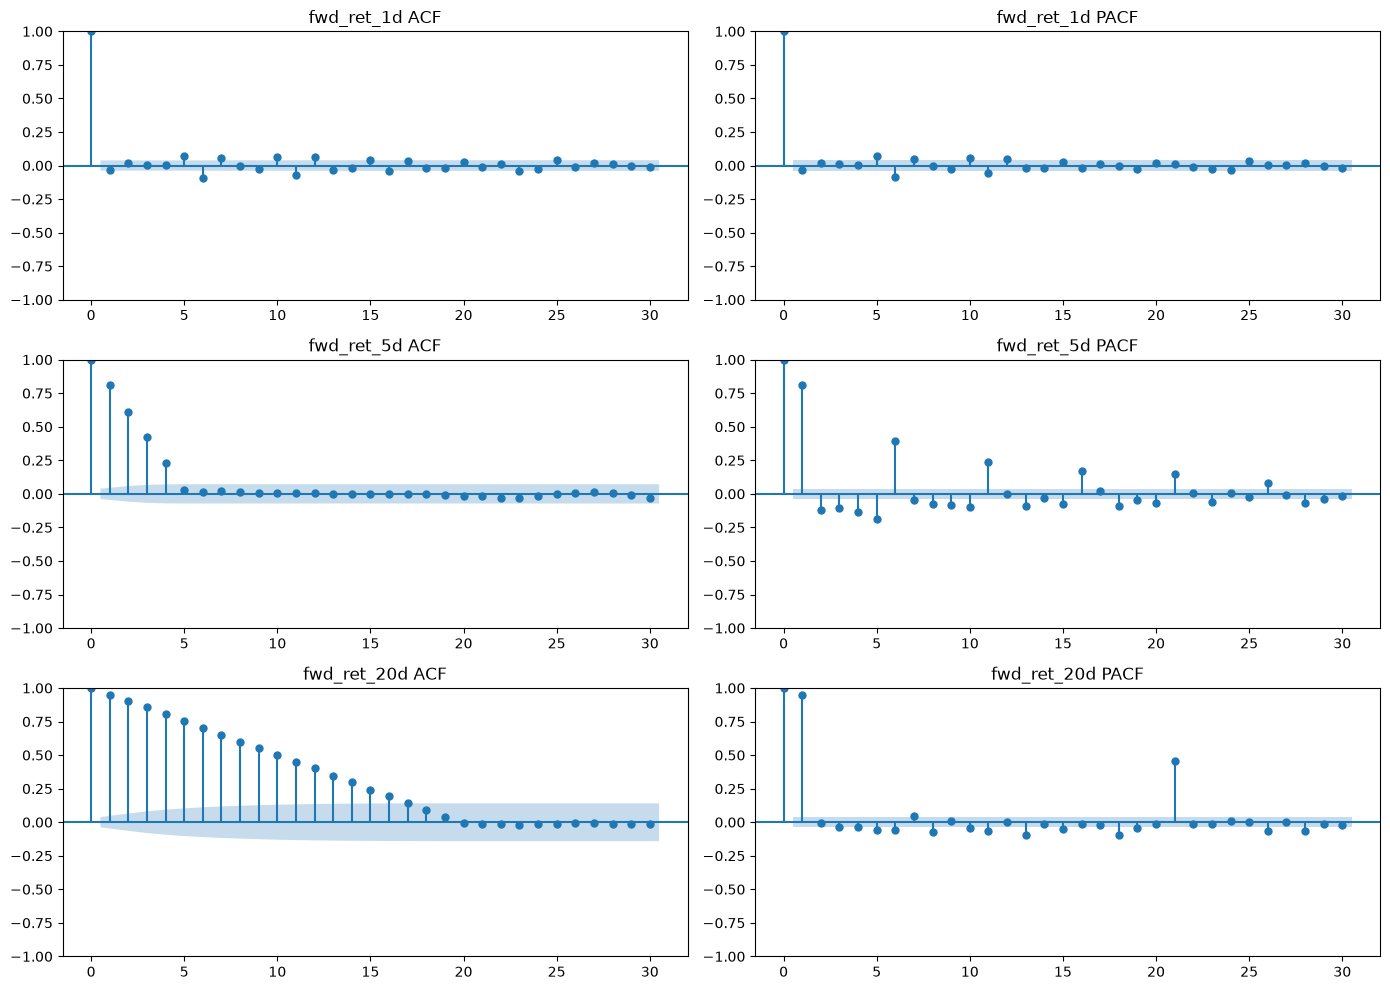

In [31]:
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

targets = feature_groups['targets']

# 1. Basic distribution stats
print(df_work[targets].describe())
print("\nup_1d base rate:")
print(df_work['up_1d'].value_counts(normalize=True))

# 2. Stationarity (ADF test) on the continuous return targets
for t in ['fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d']:
    series = df_work[t].dropna()
    result = adfuller(series)
    print(f"\n{t}: ADF stat={result[0]:.3f}, p-value={result[1]:.4f}")

# 3. Autocorrelation plots — important to check overlap-induced autocorrelation
# (fwd_ret_5d and fwd_ret_20d are overlapping windows, so they WILL show spurious ACF structure
# purely from overlap, not necessarily real predictability — keep this in mind for later)
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for i, t in enumerate(['fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d']):
    series = df_work[t].dropna()
    plot_acf(series, lags=30, ax=axes[i, 0], title=f'{t} ACF')
    plot_pacf(series, lags=30, ax=axes[i, 1], title=f'{t} PACF')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.feature_selection import mutual_info_regression

feature_cols = [c for g, cols in feature_groups.items() if g != 'targets' for c in cols]
target_cols = ['fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d']  # up_1d handled separately (binary)

results = []
for feat in feature_cols:
    for tgt in target_cols:
        sub = df_work[[feat, tgt]].dropna()
        if len(sub) < 100:
            continue
        pearson = sub[feat].corr(sub[tgt], method='pearson')
        spearman = sub[feat].corr(sub[tgt], method='spearman')
        mi = mutual_info_regression(sub[[feat]], sub[tgt], random_state=42)[0]
        results.append({'feature': feat, 'target': tgt, 'pearson': pearson, 'spearman': spearman, 'mi': mi})

ic_df = pd.DataFrame(results)
ic_df.to_csv(RESEARCH_ROOT / 'ic_map_raw.csv', index=False)  # save for reuse, avoid recompute
ic_df.sort_values('mi', ascending=False).head(20)

,feature,target,pearson,spearman,mi
2,nifty_close,fwd_ret_20d,-0.110541,-0.174524,0.302589
50,market_cap_cr,fwd_ret_20d,-0.101506,-0.173922,0.300993
8,underlying_daily_vol,fwd_ret_20d,0.233422,0.165197,0.251060
11,futures_daily_vol,fwd_ret_20d,0.228015,0.161185,0.245506
14,applicable_daily_vol,fwd_ret_20d,0.228752,0.161962,0.242552
65,dii_fut_net_pct,fwd_ret_20d,0.001096,0.047838,0.189467
71,fii_stk_fut_net_pct,fwd_ret_20d,0.021269,0.034231,0.178033
83,dii_opt_skew_pct,fwd_ret_20d,0.030855,-0.001572,0.165663
5,vix_close,fwd_ret_20d,0.234765,0.166181,0.136482
110,fii_stats_oi_net_cr,fwd_ret_20d,-0.105934,-0.150360,0.119805


In [13]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs(RESEARCH_ROOT / 'plots/lowess', exist_ok=True)

target_cols = ['fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d']

for group, features in feature_groups.items():
    if group == 'targets':
        continue

    nrows, ncols = len(features), len(target_cols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
    axes = np.atleast_2d(axes)

    for i, feat in enumerate(features):
        for j, tgt in enumerate(target_cols):
            ax = axes[i, j]
            sub = df_work[[feat, tgt]].dropna()

            if len(sub) < 50:
                ax.set_visible(False)
                continue

            ax.scatter(sub[feat], sub[tgt], s=6, alpha=0.08, color='steelblue')
            smoothed = lowess(sub[tgt], sub[feat], frac=0.3, return_sorted=True)
            ax.plot(smoothed[:, 0], smoothed[:, 1], color='red', linewidth=1.5)

            if i == 0:
                ax.set_title(tgt, fontsize=10)
            if j == 0:
                ax.set_ylabel(feat, fontsize=8)

            ax.tick_params(labelsize=6)

    plt.suptitle(f'LOWESS: {group}', fontsize=14)
    plt.tight_layout()
    plt.savefig(RESEARCH_ROOT / f'plots/lowess/{group}.png', dpi=300)
    plt.close()

    print(f'saved {group}.png')

saved price_vol.png
saved options_derived.png
saved breadth.png
saved fii_dii_positioning.png
saved options_skew.png
saved vol_futures_flow.png
saved divergence_stats.png
saved engineered_deltas.png


In [14]:
def quantile_bin_summary(df, feat, tgt, n_bins=10):
    sub = df[[feat, tgt]].dropna().copy()
    sub['bin'] = pd.qcut(sub[feat], n_bins, duplicates='drop')
    summary = sub.groupby('bin', observed=True)[tgt].agg(['mean', 'std', 'count'])
    return summary

flagged = ['max_pain_dist_pct', 'max_pain_dist_chg_5d', 'cost_of_carry', 'price_band_hits',
           'num_trades', 'vix_close', 'fii_stats_oi_net_cr', 'client_opt_skew_pct']

for feat in flagged:
    print(f"\n=== {feat} vs fwd_ret_20d ===")
    print(quantile_bin_summary(df_work, feat, 'fwd_ret_20d'))


=== max_pain_dist_pct vs fwd_ret_20d ===
                      mean       std  count
bin                                        
(-23.015, -0.97]  2.198892  6.981475    260
(-0.97, -0.391]   0.308928  5.240547    260
(-0.391, -0.122]  0.390325  5.352377    259
(-0.122, 0.11]    0.650019  3.618064    260
(0.11, 0.33]      0.834404  4.186367    260
(0.33, 0.62]      1.152941  4.490923    259
(0.62, 1.01]      1.225175  3.651548    260
(1.01, 1.631]     1.858530  3.409121    259
(1.631, 2.419]    1.324492  3.141259    260
(2.419, 5.53]     0.135866  3.402767    260

=== max_pain_dist_chg_5d vs fwd_ret_20d ===
                                  mean       std  count
bin                                                    
(-13.027999999999999, -1.27]  1.722534  6.012880    260
(-1.27, -0.705]               1.248609  5.146226    259
(-0.705, -0.419]              0.727875  5.498919    259
(-0.419, -0.199]              0.553313  4.771509    259
(-0.199, -0.0261]             0.760872  3.799588 

In [15]:
from sklearn.preprocessing import StandardScaler

candidate_cols = [c for g, cols in feature_groups.items() if g != 'targets' for c in cols]

# 1. Correlation pruning — drop features >0.9 correlated with another (redundant for HMM emissions)
corr_matrix = df_work[candidate_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print("Dropping (redundant, corr>0.9):", to_drop)

pruned_cols = [c for c in candidate_cols if c not in to_drop]

# 2. Regime-discriminative power: split by VIX tercile as rough proxy label, 
# check which features have the most separated means (ANOVA F-stat)
from sklearn.feature_selection import f_classif

vix_tercile = pd.qcut(df_work['vix_close'], 3, labels=['low', 'mid', 'high'])
sub = df_work[pruned_cols].copy()
sub = sub.loc[vix_tercile.index]

# drop rows with any NaN for this test only
valid = sub.dropna()
labels = vix_tercile.loc[valid.index]

f_scores, p_vals = f_classif(valid, labels)
disc_power = pd.DataFrame({'feature': pruned_cols, 'f_score': f_scores, 'p_value': p_vals}).sort_values('f_score', ascending=False)
print(disc_power)

Dropping (redundant, corr>0.9): ['futures_daily_vol', 'applicable_daily_vol', 'num_trades', 'market_cap_cr', 'fii_client_divergence', 'fii_stats_fut_net_pct']
                    feature      f_score        p_value
1                 vix_close  1063.320623   0.000000e+00
2      underlying_daily_vol   473.955497  4.602441e-175
11          price_band_hits   253.257486  8.106054e-101
30      fii_stats_oi_net_cr   112.487077   1.722765e-47
22      client_opt_skew_pct   110.150852   1.469996e-46
4         max_pain_dist_pct   104.831316   1.965213e-44
24         pro_opt_skew_pct    98.850413   4.941905e-42
5                     basis    90.943013   7.657666e-39
0               nifty_close    72.007069   3.993502e-31
19      fii_stk_fut_net_pct    65.322668   2.249863e-28
8                  advances    59.710835   4.703925e-26
18          pro_fut_net_pct    49.086895   1.237790e-21
20   client_stk_fut_net_pct    42.423833   7.646931e-19
23         dii_opt_skew_pct    35.086388   9.410361e-16
9

In [16]:
from joblib import Parallel, delayed
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import numpy as np

emission_raw = ['vix_close', 'underlying_daily_vol', 'price_band_hits',
                'fii_stats_oi_net_cr', 'client_opt_skew_pct',
                'max_pain_dist_pct', 'basis']

X = StandardScaler().fit_transform(df_work[emission_raw].dropna())

def fit_one_seed(X, n, cov, seed):
    try:
        model = hmm.GaussianHMM(n_components=n, covariance_type=cov,
                                n_iter=1000, tol=1e-5,
                                random_state=seed, init_params='stmc')
        model.fit(X)
        logL = model.score(X)
        _, states = model.decode(X)

        occ = np.bincount(states, minlength=n)
        if np.any(occ < max(0.01, 0.5/n) * len(X)):
            return None

        return logL, model, states

    except Exception:
        return None

results = []

print("=== HMM State Selection ===")

results = []

for cov in ['diag', 'full']:
    print(f"\n-- covariance_type='{cov}' --")

    for n in range(2, 9):

        fits = Parallel(n_jobs=-1)(
            delayed(fit_one_seed)(X, n, cov, seed)
            for seed in range(50)
        )
        fits = [r for r in fits if r]

        if not fits:
            print(f"n={n}: no valid solution")
            continue

        logL, model, states = max(fits, key=lambda x: x[0])

        d = X.shape[1]
        cov_params = n*d if cov == 'diag' else n*d*(d+1)//2
        bic = -2*logL + (n*(n-1) + n*d + cov_params) * np.log(len(X))
        occ = (np.bincount(states, minlength=n)/len(X)*100).round(1)

        print(f"n={n:2d}  logL={logL:8.1f}  BIC={bic:8.1f}  occ={occ}")

        results.append({'cov': cov, 'n': n, 'bic': bic,
                        'logL': logL, 'model': model})

best = min(results, key=lambda x: x['bic'])
print(f"\nBest: cov={best['cov']}, n={best['n']}, BIC={best['bic']:.1f}")

=== HMM State Selection ===

-- covariance_type='diag' --
n= 2  logL=-20626.2  BIC= 41488.4  occ=[32.5 67.5]
n= 3  logL=-18182.7  BIC= 36743.1  occ=[36.6 35.1 28.3]
n= 4  logL=-17161.2  BIC= 34857.6  occ=[13.1 35.1 23.1 28.8]
n=5: no valid solution
n=6: no valid solution
n=7: no valid solution
n=8: no valid solution

-- covariance_type='full' --
n= 2  logL=-17560.1  BIC= 35686.7  occ=[63.3 36.7]
n= 3  logL=-15024.3  BIC= 30922.1  occ=[36.  32.8 31.1]
n= 4  logL=-13948.0  BIC= 29092.2  occ=[16.9 33.1 23.7 26.3]
n= 5  logL=-12502.2  BIC= 26539.0  occ=[28.  26.8 17.3 13.8 14.2]
n= 6  logL=-11815.5  BIC= 25519.7  occ=[11.4 17.3 26.9 17.8  8.7 18. ]
n=7: no valid solution
n=8: no valid solution

Best: cov=full, n=6, BIC=25519.7


In [17]:
best_model = best['model']
states = best_model.predict(X)

hmm_df = df_work[emission_raw].dropna()

hmm_df_labeled = hmm_df.copy()
hmm_df_labeled['state'] = states

# state means in original (unscaled) units — easier to interpret than z-scores
state_means = hmm_df_labeled.groupby('state')[emission_raw].mean()
state_means['n_obs'] = hmm_df_labeled.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled) * 100).round(1)
print(state_means)

# also check transition matrix — persistence of each state (diagonal = self-transition prob)
print("\nTransition matrix diagonal (persistence):")
print(np.diag(best_model.transmat_))

# and map states back to actual dates to see if small states cluster around known crisis periods
for s in range(6):
    dates = hmm_df_labeled[hmm_df_labeled['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  fii_stats_oi_net_cr  \
state                                                                          
0      21.859756              0.015454       368.592593         14299.283119   
1      13.965702              0.008377       216.347345         39943.130664   
2      14.559964              0.007232       158.305398         20542.707193   
3      13.759442              0.008774       214.783262         19769.029549   
4      23.555474              0.015594       383.740088         16957.870511   
5      17.924702              0.011074       300.738298         14642.895135   

       client_opt_skew_pct  max_pain_dist_pct      basis  n_obs   pct  
state                                                                  
0                 3.971010           0.680262  14.465320    297  11.4  
1                 4.008695          -0.252349  56.887168    452  17.3  
2                 3.556335           1.315605  15.962713    704  26.9  

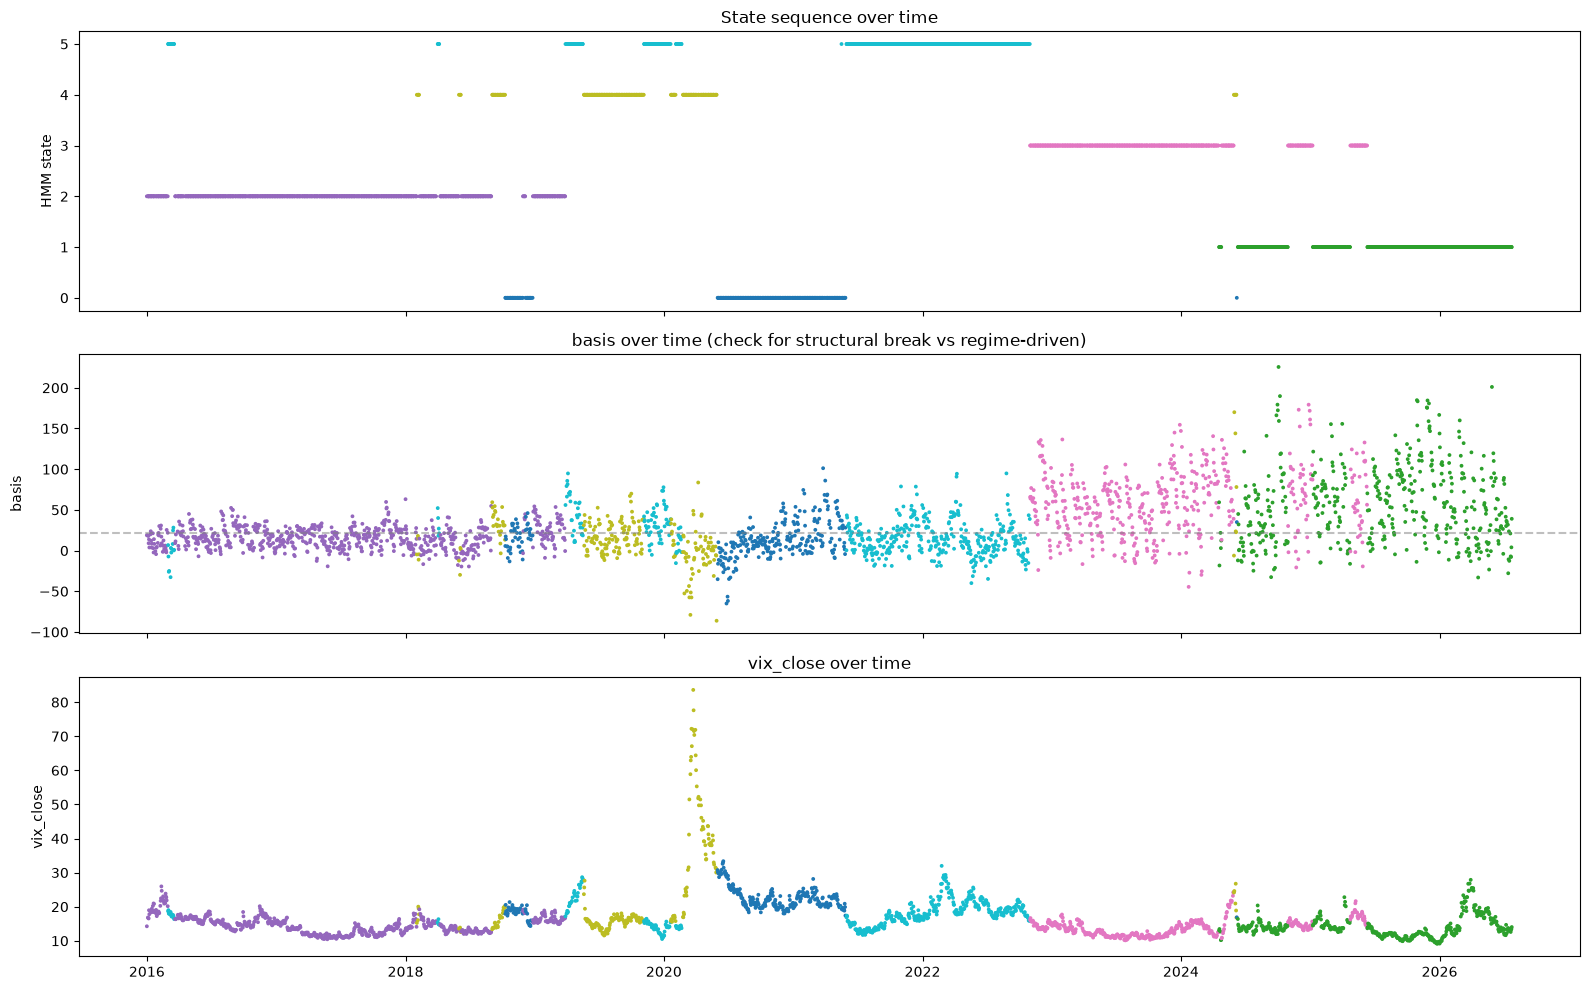

trade_date
2016-12-31    15.756680
2017-12-31    16.301008
2018-12-31    14.288821
2019-12-31    25.578367
2020-12-31     5.294643
2021-12-31    20.420161
2022-12-31    23.110081
2023-12-31    48.860366
2024-12-31    59.190562
2025-12-31    68.633333
2026-12-31    48.666667
Freq: YE-DEC, Name: basis, dtype: float64


In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# 1. state sequence over time
axes[0].scatter(hmm_df_labeled.index, hmm_df_labeled['state'], s=3, c=hmm_df_labeled['state'], cmap='tab10')
axes[0].set_ylabel('HMM state')
axes[0].set_title('State sequence over time')

# 2. basis over time, colored by state
axes[1].scatter(hmm_df_labeled.index, hmm_df_labeled['basis'], s=3, c=hmm_df_labeled['state'], cmap='tab10')
axes[1].axhline(y=hmm_df_labeled['basis'].median(), color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('basis')
axes[1].set_title('basis over time (check for structural break vs regime-driven)')

# 3. vix for reference
axes[2].scatter(hmm_df_labeled.index, hmm_df_labeled['vix_close'], s=3, c=hmm_df_labeled['state'], cmap='tab10')
axes[2].set_ylabel('vix_close')
axes[2].set_title('vix_close over time')

plt.tight_layout()
plt.savefig(RESEARCH_ROOT / f'plots/miscellanous/state_sequence.png', dpi=100)
plt.show()

# rolling 60d mean of basis, to see if it's a smooth trend/level-shift vs regime-switchy
print(hmm_df_labeled['basis'].resample('YE').mean())

# Testing HMM without Basis

In [19]:
from joblib import Parallel, delayed
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import numpy as np

emission_raw_no_basis = ['vix_close', 'underlying_daily_vol', 'price_band_hits',
                'fii_stats_oi_net_cr', 'client_opt_skew_pct',
                'max_pain_dist_pct']

X_no_basis = StandardScaler().fit_transform(df_work[emission_raw_no_basis].dropna())

n=6
cov='full'

results = []

print(f"\n-- covariance_type='{cov}' --")

fits = Parallel(n_jobs=-1)(
    delayed(fit_one_seed)(X_no_basis, n, cov, seed)
    for seed in range(50)
)
fits = [r for r in fits if r]

if not fits:
    print(f"n={n}: no valid solution")

logL, model, states = max(fits, key=lambda x: x[0])

d = X_no_basis.shape[1]
cov_params = n*d if cov == 'diag' else n*d*(d+1)//2
bic = -2*logL + (n*(n-1) + n*d + cov_params) * np.log(len(X_no_basis))
occ = (np.bincount(states, minlength=n)/len(X_no_basis)*100).round(1)

print(f"n={n:2d}  logL={logL:8.1f}  BIC={bic:8.1f}  occ={occ}")

results.append({'cov': cov, 'n': n, 'bic': bic,
                'logL': logL, 'model': model})

best_no_basis = min(results, key=lambda x: x['bic'])
print(f"\nBest: cov={best_no_basis['cov']}, n={best_no_basis['n']}, BIC={best_no_basis['bic']:.1f}")


-- covariance_type='full' --
n= 6  logL= -9812.8  BIC= 21136.6  occ=[14.9 15.1 23.7  9.4 26.2 10.7]

Best: cov=full, n=6, BIC=21136.6


In [20]:
best_model = best_no_basis['model']
states = best_model.predict(X_no_basis)

hmm_df = df_work[emission_raw].dropna()

hmm_df_labeled = hmm_df.copy()
hmm_df_labeled['state'] = states

# state means in original (unscaled) units — easier to interpret than z-scores
state_means = hmm_df_labeled.groupby('state')[emission_raw].mean()
state_means['n_obs'] = hmm_df_labeled.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled) * 100).round(1)
print(state_means)

# also check transition matrix — persistence of each state (diagonal = self-transition prob)
print("\nTransition matrix diagonal (persistence):")
print(np.diag(best_model.transmat_))

# and map states back to actual dates to see if small states cluster around known crisis periods
for s in range(6):
    dates = hmm_df_labeled[hmm_df_labeled['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  fii_stats_oi_net_cr  \
state                                                                          
0      18.493031              0.012973       308.250639         13691.736736   
1      18.567418              0.012975       307.063452         13666.522588   
2      13.097750              0.008214       216.819355         30141.607290   
3      23.312196              0.015450       376.684211         17486.096535   
4      14.306588              0.007235       168.175182         19238.680601   
5      17.969875              0.008072       226.075269         35067.295918   

       client_opt_skew_pct  max_pain_dist_pct      basis  n_obs   pct  
state                                                                  
0                 2.700767           0.373765  21.882609    391  14.9  
1                 2.828858           0.351830  23.081218    394  15.1  
2                 2.319290          -0.017935  60.575403    620  23.7  

# Testing HMM by replacing fii_stats_oi_net_cr with fii_stats_fut_net_pct

In [21]:
from joblib import Parallel, delayed
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import numpy as np

emission_raw_fii_stats_fut_net_pct = ['vix_close', 'underlying_daily_vol', 'price_band_hits',
                'fii_stats_fut_net_pct', 'client_opt_skew_pct',
                'max_pain_dist_pct', 'basis']

X_fii_stats_fut_net_pct = StandardScaler().fit_transform(df_work[emission_raw_fii_stats_fut_net_pct].dropna())

results = []

for cov in ['diag', 'full']:
    print(f"\n-- covariance_type='{cov}' --")

    for n in range(2, 9):

        fits = Parallel(n_jobs=-1)(
            delayed(fit_one_seed)(X_fii_stats_fut_net_pct, n, cov, seed)
            for seed in range(50)
        )
        fits = [r for r in fits if r]

        if not fits:
            print(f"n={n}: no valid solution")
            continue

        logL, model, states = max(fits, key=lambda x: x[0])

        d = X_fii_stats_fut_net_pct.shape[1]
        cov_params = n*d if cov == 'diag' else n*d*(d+1)//2
        bic = -2*logL + (n*(n-1) + n*d + cov_params) * np.log(len(X_fii_stats_fut_net_pct))
        occ = (np.bincount(states, minlength=n)/len(X_fii_stats_fut_net_pct)*100).round(1)

        print(f"n={n:2d}  logL={logL:8.1f}  BIC={bic:8.1f}  occ={occ}")

        results.append({'cov': cov, 'n': n, 'bic': bic,
                        'logL': logL, 'model': model})

best_fii_stats_fut_net_pct = min(results, key=lambda x: x['bic'])
print(f"\nBest: cov={best_fii_stats_fut_net_pct['cov']}, n={best_fii_stats_fut_net_pct['n']}, BIC={best_fii_stats_fut_net_pct['bic']:.1f}")


-- covariance_type='diag' --
n= 2  logL=-21304.8  BIC= 42845.8  occ=[70.4 29.6]
n= 3  logL=-19174.4  BIC= 38726.6  occ=[41.2 28.8 29.9]
n=4: no valid solution
n= 5  logL=-19145.7  BIC= 38999.6  occ=[17.2 20.1 17.  20.  25.6]
n=6: no valid solution
n=7: no valid solution
n=8: no valid solution

-- covariance_type='full' --
n= 2  logL=-18704.6  BIC= 37975.9  occ=[64.9 35.1]
n= 3  logL=-16184.6  BIC= 33242.7  occ=[32.3 34.3 33.3]
n= 4  logL=-14879.5  BIC= 30955.2  occ=[20.6 27.1 30.8 21.4]
n= 5  logL=-14203.0  BIC= 29940.5  occ=[16.6 15.  19.5 26.7 22.2]
n=6: no valid solution
n=7: no valid solution
n=8: no valid solution

Best: cov=full, n=5, BIC=29940.5


In [22]:
best_model = best_fii_stats_fut_net_pct['model']
states = best_model.predict(X_fii_stats_fut_net_pct)

hmm_df = df_work[emission_raw_fii_stats_fut_net_pct].dropna()

hmm_df_labeled_X_fii_stats_fut_net_pct = hmm_df.copy()
hmm_df_labeled_X_fii_stats_fut_net_pct['state'] = states

# state means in original (unscaled) units — easier to interpret than z-scores
state_means = hmm_df_labeled_X_fii_stats_fut_net_pct.groupby('state')[emission_raw_fii_stats_fut_net_pct].mean()
state_means['n_obs'] = hmm_df_labeled_X_fii_stats_fut_net_pct.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled_X_fii_stats_fut_net_pct) * 100).round(1)
print(state_means)

# also check transition matrix — persistence of each state (diagonal = self-transition prob)
print("\nTransition matrix diagonal (persistence):")
print(np.diag(best_model.transmat_))

# and map states back to actual dates to see if small states cluster around known crisis periods
for s in range(best_model.n_components):
    dates = hmm_df_labeled_X_fii_stats_fut_net_pct[hmm_df_labeled_X_fii_stats_fut_net_pct['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  \
state                                                     
0      12.076377              0.008719       187.460829   
1      14.444324              0.008387       241.566327   
2      18.517034              0.011256       280.311765   
3      14.529975              0.007261       158.180258   
4      21.919449              0.014482       374.654045   

       fii_stats_fut_net_pct  client_opt_skew_pct  max_pain_dist_pct  \
state                                                                  
0                  -0.912143             2.861843           0.009922   
1                  -1.450255             1.914872          -0.064886   
2                  -0.176490             3.845490           0.017830   
3                  -1.381202             3.625236           1.294675   
4                  -1.064182             6.299312           0.539849   

           basis  n_obs   pct  
state                          
0      56.862673 

# Keeping HMM with fii_stats_fut_net_pct, replacing basis with basis_chg_5d

In [ ]:
from joblib import Parallel, delayed
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import numpy as np

emission_raw_basis_chg_5d = ['vix_close', 'underlying_daily_vol', 'price_band_hits',
                'fii_stats_fut_net_pct', 'client_opt_skew_pct',
                'max_pain_dist_pct', 'basis_chg_5d']

X_basis_chg_5d = StandardScaler().fit_transform(df_work[emission_raw_basis_chg_5d].dropna())

results = []

for cov in ['diag', 'full']:
    print(f"\n-- covariance_type='{cov}' --")

    for n in range(2, 9):

        fits = Parallel(n_jobs=-1)(
            delayed(fit_one_seed)(X_basis_chg_5d, n, cov, seed)
            for seed in range(50)
        )
        fits = [r for r in fits if r]

        if not fits:
            print(f"n={n}: no valid solution")
            continue

        logL, model, states = max(fits, key=lambda x: x[0])

        d = X_basis_chg_5d.shape[1]
        cov_params = n*d if cov == 'diag' else n*d*(d+1)//2
        bic = -2*logL + (n*(n-1) + n*d + cov_params) * np.log(len(X_basis_chg_5d))
        occ = (np.bincount(states, minlength=n)/len(X_basis_chg_5d)*100).round(1)

        print(f"n={n:2d}  logL={logL:8.1f}  BIC={bic:8.1f}  occ={occ}")

        results.append({'cov': cov, 'n': n, 'bic': bic,
                        'logL': logL, 'model': model})

best_basis_chg_5d = min(results, key=lambda x: x['bic'])
print(f"\nBest: cov={best_basis_chg_5d['cov']}, n={best_basis_chg_5d['n']}, BIC={best_basis_chg_5d['bic']:.1f}")


-- covariance_type='diag' --
n= 2  logL=-21379.8  BIC= 42995.6  occ=[30.3 69.7]
n= 3  logL=-19420.5  BIC= 39218.6  occ=[30.3 41.1 28.6]
n= 4  logL=-19421.9  BIC= 39378.8  occ=[15.2 44.8 24.6 15.4]
n=5: no valid solution
n=6: no valid solution
n=7: no valid solution
n=8: no valid solution

-- covariance_type='full' --
n= 2  logL=-19005.0  BIC= 38576.5  occ=[64.6 35.4]
n= 3  logL=-16607.6  BIC= 34088.5  occ=[32.6 32.9 34.5]
n= 4  logL=-15287.9  BIC= 31771.6  occ=[27.7 27.6 12.6 32.2]
n= 5  logL=-15275.9  BIC= 32086.0  occ=[13.6 27.6 13.6 13.  32.2]
n= 6  logL=-13959.1  BIC= 29806.5  occ=[14.6 31.4  9.  17.3 13.3 14.4]
n= 7  logL=-14569.3  BIC= 31396.5  occ=[ 7.5  7.3 18.2  7.8 18.8 33.2  7.3]
n=8: no valid solution

Best: cov=full, n=6, BIC=29806.5


In [24]:
best_model = best_basis_chg_5d['model']
states = best_model.predict(X_basis_chg_5d)

hmm_df = df_work[emission_raw_basis_chg_5d].dropna()

hmm_df_labeled_basis_chg_5d = hmm_df.copy()
hmm_df_labeled_basis_chg_5d['state'] = states

# state means in original (unscaled) units — easier to interpret than z-scores
state_means = hmm_df_labeled_basis_chg_5d.groupby('state')[emission_raw_basis_chg_5d].mean()
state_means['n_obs'] = hmm_df_labeled_basis_chg_5d.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled_basis_chg_5d) * 100).round(1)
print(state_means)

# also check transition matrix — persistence of each state (diagonal = self-transition prob)
print("\nTransition matrix diagonal (persistence):")
print(np.diag(best_model.transmat_))

# and map states back to actual dates to see if small states cluster around known crisis periods
for s in range(best_model.n_components):
    dates = hmm_df_labeled_basis_chg_5d[hmm_df_labeled_basis_chg_5d['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  \
state                                                     
0      18.985217              0.014425       366.976378   
1      14.641833              0.007300       186.514007   
2      26.327639              0.016487       385.303419   
3      14.098999              0.008301       234.849558   
4      19.649675              0.010988       248.612717   
5      12.118932              0.008904       188.806366   

       fii_stats_fut_net_pct  client_opt_skew_pct  max_pain_dist_pct  \
state                                                                  
0                  -0.813123             3.587664           0.731752   
1                  -1.694373             4.509488           1.223959   
2                  -1.041838             7.594658          -0.068317   
3                  -1.501814             2.146217          -0.064477   
4                   0.817746             3.514422          -0.080397   
5                  -0.6

# Trying Rolled Values

In [30]:
emission_raw = ['vix_close', 'underlying_daily_vol', 'price_band_hits', 
                 'fii_stats_fut_net_pct', 'client_opt_skew_pct', 'max_pain_dist_pct', 'basis_chg_5d']

roll_window = 252  # ~1 trading year
rolled = df_work[emission_raw].copy()
rolled_z = (rolled - rolled.rolling(roll_window, min_periods=60).mean()) / rolled.rolling(roll_window, min_periods=60).std()
rolled_z = rolled_z.dropna()

print(rolled_z.describe())  # sanity check: means should be ~0 throughout, no drift
print(rolled_z.index.min(), rolled_z.index.max())  # note: loses first ~year to warmup

         vix_close  underlying_daily_vol  price_band_hits  \
count  2552.000000           2552.000000      2552.000000   
mean     -0.123548             -0.369221         0.133734   
std       1.296208              1.364218         1.198925   
min      -3.116753             -2.458925        -4.978166   
25%      -0.944565             -1.406813        -0.733063   
50%      -0.317434             -0.542573        -0.074122   
75%       0.423521              0.331047         0.766133   
max       7.758540              7.552071         7.730337   

       fii_stats_fut_net_pct  client_opt_skew_pct  max_pain_dist_pct  \
count            2552.000000          2552.000000        2552.000000   
mean               -0.016280             0.013735          -0.080155   
std                 1.033466             1.005798           1.056664   
min                -3.247744            -2.808031          -7.139720   
25%                -0.654223            -0.721628          -0.601219   
50%               

In [35]:
X_rolled = rolled_z.values

results_rolled = []

for cov in ['diag', 'full']:
    print(f"\n-- covariance_type='{cov}' --")

    for n in range(2, 16):

        fits = Parallel(n_jobs=-1)(
            delayed(fit_one_seed)(X_rolled, n, cov, seed)
            for seed in range(50)
        )
        fits = [r for r in fits if r]

        if not fits:
            print(f"n={n}: no valid solution")
            continue

        logL, model, states = max(fits, key=lambda x: x[0])

        d = X_rolled.shape[1]
        cov_params = n*d if cov == 'diag' else n*d*(d+1)//2
        bic = -2*logL + (n*(n-1) + n*d + cov_params) * np.log(len(X_rolled))
        occ = (np.bincount(states, minlength=n)/len(X_rolled)*100).round(1)

        print(f"n={n:2d}  logL={logL:8.1f}  BIC={bic:8.1f}  occ={occ}")

        results_rolled.append({
            'cov': cov,
            'n': n,
            'bic': bic,
            'logL': logL,
            'model': model
        })
best_rolled = min(results_rolled, key=lambda x: x['bic'])
print(f"\nBest: cov={best_rolled['cov']}, n={best_rolled['n']}, BIC={best_rolled['bic']:.1f}")


-- covariance_type='diag' --
n= 2  logL=-25022.8  BIC= 50280.9  occ=[46.8 53.2]
n= 3  logL=-23596.5  BIC= 47569.5  occ=[24.3 30.  45.7]
n= 4  logL=-22823.5  BIC= 46180.4  occ=[28.9 25.4 17.3 28.4]
n= 5  logL=-22244.8  BIC= 45195.6  occ=[24.5 18.3 18.1 15.4 23.8]
n= 6  logL=-21698.7  BIC= 44291.8  occ=[16.1 16.9 20.5 16.7 15.  14.8]
n= 7  logL=-21276.7  BIC= 43651.6  occ=[13.8 14.7 10.6 12.5 14.3 16.1 18.1]
n= 8  logL=-20957.5  BIC= 43232.9  occ=[13.7 10.2 13.7 16.9  6.7 19.6  6.4 12.8]
n= 9  logL=-20566.1  BIC= 42685.4  occ=[11.2  9.3 14.7 12.9  8.7  7.2  5.7 11.9 18.4]
n=10  logL=-20238.0  BIC= 42280.3  occ=[ 9.8 14.2 12.8  5.7 11.7  7.7 13.   5.4  8.4 11.4]
n=11  logL=-19939.9  BIC= 41950.7  occ=[ 8.4  4.8 12.9  5.4 15.1  5.4 13.1  5.7 11.6  9.7  7.8]
n=12  logL=-19713.6  BIC= 41780.6  occ=[ 6.2  5.7 15.7 12.9  6.9  8.8  5.6  8.9  7.4  5.9  9.7  6.2]
n=13  logL=-19688.8  BIC= 42029.1  occ=[ 5.8 11.5 13.2  6.3  4.7  6.9  5.1 11.3  5.  11.9  7.8  4.1  6.4]
n=14: no valid solution
n=15

# 10 States

In [48]:
best_model = best_rolled['model']
states = best_model.predict(X_rolled)

hmm_df = df_work.loc[rolled_z.index, emission_raw].copy()

hmm_df_labeled_rolled = hmm_df.copy()
hmm_df_labeled_rolled['state'] = states

# state means in original (unscaled) units — easier to interpret than z-scores
state_means = hmm_df_labeled_rolled.groupby('state')[emission_raw].mean()
state_means['n_obs'] = hmm_df_labeled_rolled.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled_rolled) * 100).round(1)
print(state_means)

# also check transition matrix — persistence of each state (diagonal = self-transition prob)
print("\nTransition matrix diagonal (persistence):")
print(np.diag(best_model.transmat_))

# and map states back to actual dates to see if small states cluster around known crisis periods
for s in range(best_model.n_components):
    dates = hmm_df_labeled_rolled[hmm_df_labeled_rolled['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  \
state                                                     
0      17.966125              0.011462       227.000000   
1      22.008039              0.016363       395.922156   
2      17.447374              0.010923       249.382671   
3      15.038887              0.008506       213.314488   
4      12.401922              0.009474       221.799242   
5      25.614965              0.015612       357.545455   
6      15.213762              0.009241       234.629808   
7      13.480000              0.008805       204.087324   
8      19.957677              0.009080       258.783465   
9      13.827846              0.007098       251.166205   

       fii_stats_fut_net_pct  client_opt_skew_pct  max_pain_dist_pct  \
state                                                                  
0                  -3.607792             4.027833           0.474026   
1                   1.760958             2.755150           0.940083   
2  

In [49]:
all_feature_cols = [c for g, cols in feature_groups.items() if g != 'targets' for c in cols]

roll_window = 252
all_rolled = df_work[all_feature_cols].copy()
all_rolled_z = (all_rolled - all_rolled.rolling(roll_window, min_periods=60).mean()) / all_rolled.rolling(roll_window, min_periods=60).std()

# align to whichever state assignment you want to test (e.g. n=8 or n=10)
common_idx = all_rolled_z.dropna().index.intersection(hmm_df_labeled_rolled.index)
char_df_v3 = all_rolled_z.loc[common_idx].copy()
char_df_v3['state'] = hmm_df_labeled_rolled.loc[common_idx, 'state']

effect_sizes_v3 = []
for s in sorted(char_df_v3['state'].unique()):
    in_state = char_df_v3[char_df_v3['state']==s]
    out_state = char_df_v3[char_df_v3['state']!=s]
    for feat in all_feature_cols:
        m1, m2 = in_state[feat].mean(), out_state[feat].mean()
        pooled_std = np.sqrt((in_state[feat].var() + out_state[feat].var()) / 2)
        d = (m1 - m2) / pooled_std if pooled_std > 0 else 0
        effect_sizes_v3.append({'state': s, 'feature': feat, 'cohens_d': d})

eff_df_v3 = pd.DataFrame(effect_sizes_v3)
for s in sorted(char_df_v3['state'].unique()):
    top = eff_df_v3[eff_df_v3['state']==s].reindex(
        eff_df_v3[eff_df_v3['state']==s]['cohens_d'].abs().sort_values(ascending=False).index).head(5)
    print(f"\n=== State {s} (rolling-normalized diagnostics) ===")
    print(top[['feature','cohens_d']].round(3))


=== State 0 (rolling-normalized diagnostics) ===
                feature  cohens_d
13      price_band_hits    -1.169
23  fii_stk_fut_net_pct    -0.608
21      dii_fut_net_pct    -0.576
1             vix_close    -0.571
16        market_cap_cr     0.494

=== State 1 (rolling-normalized diagnostics) ===
                  feature  cohens_d
69    client_opt_skew_pct    -1.064
62         fii_pe_net_pct    -1.015
64        dii_fut_net_pct    -0.955
60        fii_fut_net_pct     0.940
77  fii_client_divergence     0.825

=== State 2 (rolling-normalized diagnostics) ===
                 feature  cohens_d
88  underlying_daily_vol     2.173
90  applicable_daily_vol     2.170
89     futures_daily_vol     2.143
87             vix_close     0.726
93                 basis    -0.562

=== State 3 (rolling-normalized diagnostics) ===
                  feature  cohens_d
131  underlying_daily_vol    -0.959
133  applicable_daily_vol    -0.933
132     futures_daily_vol    -0.914
145         market_cap_cr 

# 9 States

In [62]:
# Pick the model you want
n_states = 9
cov_type = 'full'

selected = next(
    r for r in results_rolled
    if r['n'] == n_states and r['cov'] == cov_type
)

model = selected['model']
states = model.predict(X_rolled)

hmm_df_labeled_rolled = None
hmm_df_labeled_rolled = df_work.loc[rolled_z.index, emission_raw].copy()
hmm_df_labeled_rolled['state'] = states

# State means
state_means = hmm_df_labeled_rolled.groupby('state')[emission_raw].mean()
state_means['n_obs'] = hmm_df_labeled_rolled.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled_rolled) * 100).round(1)
print(state_means)

# Persistence
print("\nTransition matrix diagonal (persistence):")
print(np.diag(model.transmat_))

# Date ranges
for s in range(model.n_components):
    dates = hmm_df_labeled_rolled[hmm_df_labeled_rolled['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  \
state                                                     
0      13.702153              0.007374       270.555556   
1      12.466992              0.009437       213.360406   
2      16.062203              0.008845       243.967626   
3      19.362280              0.008279       258.308370   
4      13.853330              0.007660       160.100000   
5      20.910833              0.014507       331.608025   
6      12.896171              0.009278       226.800664   
7      21.453658              0.013153       311.509653   
8      16.553078              0.010354       220.936916   

       fii_stats_fut_net_pct  client_opt_skew_pct  max_pain_dist_pct  \
state                                                                  
0                  -1.494271             4.747396           1.548830   
1                  -1.337005             2.451371           0.340940   
2                  -2.505036             3.818094           0.

In [63]:
all_feature_cols = [c for g, cols in feature_groups.items() if g != 'targets' for c in cols]

roll_window = 252
all_rolled = df_work[all_feature_cols].copy()
all_rolled_z = (all_rolled - all_rolled.rolling(roll_window, min_periods=60).mean()) / all_rolled.rolling(roll_window, min_periods=60).std()

# align to whichever state assignment you want to test (e.g. n=8 or n=10)
common_idx = all_rolled_z.dropna().index.intersection(hmm_df_labeled_rolled.index)
char_df_v3 = all_rolled_z.loc[common_idx].copy()
char_df_v3['state'] = hmm_df_labeled_rolled.loc[common_idx, 'state']

effect_sizes_v3 = []
for s in sorted(char_df_v3['state'].unique()):
    in_state = char_df_v3[char_df_v3['state']==s]
    out_state = char_df_v3[char_df_v3['state']!=s]
    for feat in all_feature_cols:
        m1, m2 = in_state[feat].mean(), out_state[feat].mean()
        pooled_std = np.sqrt((in_state[feat].var() + out_state[feat].var()) / 2)
        d = (m1 - m2) / pooled_std if pooled_std > 0 else 0
        effect_sizes_v3.append({'state': s, 'feature': feat, 'cohens_d': d})

eff_df_v3 = pd.DataFrame(effect_sizes_v3)
for s in sorted(char_df_v3['state'].unique()):
    top = eff_df_v3[eff_df_v3['state']==s].reindex(
        eff_df_v3[eff_df_v3['state']==s]['cohens_d'].abs().sort_values(ascending=False).index).head(5)
    print(f"\n=== State {s} (rolling-normalized diagnostics) ===")
    print(top[['feature','cohens_d']].round(3))


=== State 0 (rolling-normalized diagnostics) ===
                   feature  cohens_d
13         price_band_hits     1.189
23     fii_stk_fut_net_pct     1.016
24  client_stk_fut_net_pct    -0.771
17         fii_fut_net_pct    -0.684
34   fii_client_divergence    -0.673

=== State 1 (rolling-normalized diagnostics) ===
                 feature  cohens_d
46     futures_daily_vol    -1.808
47  applicable_daily_vol    -1.785
45  underlying_daily_vol    -1.765
44             vix_close    -1.743
84   vix_realized_spread    -1.184

=== State 2 (rolling-normalized diagnostics) ===
                  feature  cohens_d
127   vix_realized_spread     0.956
88   underlying_daily_vol    -0.713
90   applicable_daily_vol    -0.680
89      futures_daily_vol    -0.673
102         market_cap_cr     0.624

=== State 3 (rolling-normalized diagnostics) ===
                 feature  cohens_d
170  vix_realized_spread     2.532
130            vix_close     1.938
166           vix_chg_5d     0.662
165  fii_sta

# 8 States

In [64]:
# Pick the model you want
n_states = 8
cov_type = 'full'

selected = next(
    r for r in results_rolled
    if r['n'] == n_states and r['cov'] == cov_type
)

model = selected['model']
states = model.predict(X_rolled)

hmm_df_labeled_rolled = None
hmm_df_labeled_rolled = df_work.loc[rolled_z.index, emission_raw].copy()
hmm_df_labeled_rolled['state'] = states

# State means
state_means = hmm_df_labeled_rolled.groupby('state')[emission_raw].mean()
state_means['n_obs'] = hmm_df_labeled_rolled.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled_rolled) * 100).round(1)
print(state_means)

# Persistence
print("\nTransition matrix diagonal (persistence):")
print(np.diag(model.transmat_))

# Date ranges
for s in range(model.n_components):
    dates = hmm_df_labeled_rolled[hmm_df_labeled_rolled['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  \
state                                                     
0      14.493235              0.008595       253.987616   
1      13.682740              0.009603       217.000000   
2      19.132274              0.008765       253.183946   
3      19.567493              0.013313       316.452830   
4      15.278404              0.008392       231.334043   
5      12.506505              0.008603       199.522782   
6      17.302480              0.011112       229.644000   
7      23.356049              0.014103       327.512953   

       fii_stats_fut_net_pct  client_opt_skew_pct  max_pain_dist_pct  \
state                                                                  
0                  -4.032508             7.494396           0.385766   
1                  -3.208341             3.480175          -0.019364   
2                  -1.283010             3.623077           0.231555   
3                   0.632480             2.997493

In [65]:
all_feature_cols = [c for g, cols in feature_groups.items() if g != 'targets' for c in cols]

roll_window = 252
all_rolled = df_work[all_feature_cols].copy()
all_rolled_z = (all_rolled - all_rolled.rolling(roll_window, min_periods=60).mean()) / all_rolled.rolling(roll_window, min_periods=60).std()

# align to whichever state assignment you want to test (e.g. n=8 or n=10)
common_idx = all_rolled_z.dropna().index.intersection(hmm_df_labeled_rolled.index)
char_df_v3 = all_rolled_z.loc[common_idx].copy()
char_df_v3['state'] = hmm_df_labeled_rolled.loc[common_idx, 'state']

effect_sizes_v3 = []
for s in sorted(char_df_v3['state'].unique()):
    in_state = char_df_v3[char_df_v3['state']==s]
    out_state = char_df_v3[char_df_v3['state']!=s]
    for feat in all_feature_cols:
        m1, m2 = in_state[feat].mean(), out_state[feat].mean()
        pooled_std = np.sqrt((in_state[feat].var() + out_state[feat].var()) / 2)
        d = (m1 - m2) / pooled_std if pooled_std > 0 else 0
        effect_sizes_v3.append({'state': s, 'feature': feat, 'cohens_d': d})

eff_df_v3 = pd.DataFrame(effect_sizes_v3)
for s in sorted(char_df_v3['state'].unique()):
    top = eff_df_v3[eff_df_v3['state']==s].reindex(
        eff_df_v3[eff_df_v3['state']==s]['cohens_d'].abs().sort_values(ascending=False).index).head(5)
    print(f"\n=== State {s} (rolling-normalized diagnostics) ===")
    print(top[['feature','cohens_d']].round(3))


=== State 0 (rolling-normalized diagnostics) ===
                 feature  cohens_d
25      fii_opt_skew_pct    -1.041
26   client_opt_skew_pct     1.031
19        fii_pe_net_pct     0.951
2   underlying_daily_vol     0.917
4   applicable_daily_vol     0.900

=== State 1 (rolling-normalized diagnostics) ===
                 feature  cohens_d
47  applicable_daily_vol    -2.026
45  underlying_daily_vol    -2.016
46     futures_daily_vol    -2.016
44             vix_close    -0.988
56       price_band_hits    -0.894

=== State 2 (rolling-normalized diagnostics) ===
                 feature  cohens_d
127  vix_realized_spread     1.913
87             vix_close     1.639
123           vix_chg_5d     0.537
113     dii_opt_skew_pct     0.516
109  fii_stk_fut_net_pct     0.456

=== State 3 (rolling-normalized diagnostics) ===
                   feature  cohens_d
150        dii_fut_net_pct    -0.778
146        fii_fut_net_pct     0.716
155    client_opt_skew_pct    -0.714
163  fii_client_diverg

# 7 States

In [66]:
# Pick the model you want
n_states = 7
cov_type = 'full'

selected = next(
    r for r in results_rolled
    if r['n'] == n_states and r['cov'] == cov_type
)

model = selected['model']
states = model.predict(X_rolled)

hmm_df_labeled_rolled = None
hmm_df_labeled_rolled = df_work.loc[rolled_z.index, emission_raw].copy()
hmm_df_labeled_rolled['state'] = states

# State means
state_means = hmm_df_labeled_rolled.groupby('state')[emission_raw].mean()
state_means['n_obs'] = hmm_df_labeled_rolled.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled_rolled) * 100).round(1)
print(state_means)

# Persistence
print("\nTransition matrix diagonal (persistence):")
print(np.diag(model.transmat_))

# Date ranges
for s in range(model.n_components):
    dates = hmm_df_labeled_rolled[hmm_df_labeled_rolled['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  \
state                                                     
0      15.124172              0.009316       223.238390   
1      18.794934              0.008934       241.537705   
2      13.884038              0.007168       264.806154   
3      12.804436              0.009021       207.909390   
4      23.118173              0.014292       323.730909   
5      20.273753              0.013955       322.626039   
6      15.296805              0.008594       207.455056   

       fii_stats_fut_net_pct  client_opt_skew_pct  max_pain_dist_pct  \
state                                                                  
0                  -0.882198             3.948142          -0.131149   
1                  -2.554230             4.105377           0.080620   
2                  -2.314954             5.323200           1.391091   
3                  -1.309242             2.100626           0.527347   
4                  -0.736218        

In [67]:
all_feature_cols = [c for g, cols in feature_groups.items() if g != 'targets' for c in cols]

roll_window = 252
all_rolled = df_work[all_feature_cols].copy()
all_rolled_z = (all_rolled - all_rolled.rolling(roll_window, min_periods=60).mean()) / all_rolled.rolling(roll_window, min_periods=60).std()

# align to whichever state assignment you want to test (e.g. n=8 or n=10)
common_idx = all_rolled_z.dropna().index.intersection(hmm_df_labeled_rolled.index)
char_df_v3 = all_rolled_z.loc[common_idx].copy()
char_df_v3['state'] = hmm_df_labeled_rolled.loc[common_idx, 'state']

effect_sizes_v3 = []
for s in sorted(char_df_v3['state'].unique()):
    in_state = char_df_v3[char_df_v3['state']==s]
    out_state = char_df_v3[char_df_v3['state']!=s]
    for feat in all_feature_cols:
        m1, m2 = in_state[feat].mean(), out_state[feat].mean()
        pooled_std = np.sqrt((in_state[feat].var() + out_state[feat].var()) / 2)
        d = (m1 - m2) / pooled_std if pooled_std > 0 else 0
        effect_sizes_v3.append({'state': s, 'feature': feat, 'cohens_d': d})

eff_df_v3 = pd.DataFrame(effect_sizes_v3)
for s in sorted(char_df_v3['state'].unique()):
    top = eff_df_v3[eff_df_v3['state']==s].reindex(
        eff_df_v3[eff_df_v3['state']==s]['cohens_d'].abs().sort_values(ascending=False).index).head(5)
    print(f"\n=== State {s} (rolling-normalized diagnostics) ===")
    print(top[['feature','cohens_d']].round(3))


=== State 0 (rolling-normalized diagnostics) ===
                 feature  cohens_d
2   underlying_daily_vol     1.522
4   applicable_daily_vol     1.482
3      futures_daily_vol     1.436
23   fii_stk_fut_net_pct     0.648
41   vix_realized_spread    -0.637

=== State 1 (rolling-normalized diagnostics) ===
                feature  cohens_d
84  vix_realized_spread     1.432
44            vix_close     1.262
70     dii_opt_skew_pct     0.702
80           vix_chg_5d     0.465
48                  pcr    -0.422

=== State 2 (rolling-normalized diagnostics) ===
                   feature  cohens_d
99         price_band_hits     1.493
109    fii_stk_fut_net_pct     0.821
103        fii_fut_net_pct    -0.734
120  fii_client_divergence    -0.709
113       dii_opt_skew_pct    -0.590

=== State 3 (rolling-normalized diagnostics) ===
                  feature  cohens_d
132     futures_daily_vol    -2.192
133  applicable_daily_vol    -2.171
131  underlying_daily_vol    -2.133
130             vix_

# 6 States

In [70]:
# Pick the model you want
n_states = 6
cov_type = 'full'

selected = next(
    r for r in results_rolled
    if r['n'] == n_states and r['cov'] == cov_type
)

model = selected['model']
states = model.predict(X_rolled)

hmm_df_labeled_rolled = None
hmm_df_labeled_rolled = df_work.loc[rolled_z.index, emission_raw].copy()
hmm_df_labeled_rolled['state'] = states

# State means
state_means = hmm_df_labeled_rolled.groupby('state')[emission_raw].mean()
state_means['n_obs'] = hmm_df_labeled_rolled.groupby('state').size()
state_means['pct'] = (state_means['n_obs'] / len(hmm_df_labeled_rolled) * 100).round(1)
print(state_means)

# Persistence
print("\nTransition matrix diagonal (persistence):")
print(np.diag(model.transmat_))

# Date ranges
for s in range(model.n_components):
    dates = hmm_df_labeled_rolled[hmm_df_labeled_rolled['state'] == s].index
    print(f"\nState {s} ({len(dates)} obs): {dates.min().date()} to {dates.max().date()}")

       vix_close  underlying_daily_vol  price_band_hits  \
state                                                     
0      14.755167              0.009037       238.208081   
1      18.911279              0.012477       302.373166   
2      23.338958              0.014296       319.257576   
3      12.807227              0.009039       208.138843   
4      15.173810              0.008489       208.986631   
5      18.144815              0.008085       257.780415   

       fii_stats_fut_net_pct  client_opt_skew_pct  max_pain_dist_pct  \
state                                                                  
0                  -1.890869             5.377556           0.351059   
1                  -0.278176             2.785325           0.997369   
2                  -1.123977             8.331212          -0.802724   
3                  -1.275488             2.081603           0.535674   
4                  -0.298155             1.580374           1.127022   
5                  -1.8

In [71]:
all_feature_cols = [c for g, cols in feature_groups.items() if g != 'targets' for c in cols]

roll_window = 252
all_rolled = df_work[all_feature_cols].copy()
all_rolled_z = (all_rolled - all_rolled.rolling(roll_window, min_periods=60).mean()) / all_rolled.rolling(roll_window, min_periods=60).std()

# align to whichever state assignment you want to test (e.g. n=8 or n=10)
common_idx = all_rolled_z.dropna().index.intersection(hmm_df_labeled_rolled.index)
char_df_v3 = all_rolled_z.loc[common_idx].copy()
char_df_v3['state'] = hmm_df_labeled_rolled.loc[common_idx, 'state']

effect_sizes_v3 = []
for s in sorted(char_df_v3['state'].unique()):
    in_state = char_df_v3[char_df_v3['state']==s]
    out_state = char_df_v3[char_df_v3['state']!=s]
    for feat in all_feature_cols:
        m1, m2 = in_state[feat].mean(), out_state[feat].mean()
        pooled_std = np.sqrt((in_state[feat].var() + out_state[feat].var()) / 2)
        d = (m1 - m2) / pooled_std if pooled_std > 0 else 0
        effect_sizes_v3.append({'state': s, 'feature': feat, 'cohens_d': d})

eff_df_v3 = pd.DataFrame(effect_sizes_v3)
for s in sorted(char_df_v3['state'].unique()):
    top = eff_df_v3[eff_df_v3['state']==s].reindex(
        eff_df_v3[eff_df_v3['state']==s]['cohens_d'].abs().sort_values(ascending=False).index).head(5)
    print(f"\n=== State {s} (rolling-normalized diagnostics) ===")
    print(top[['feature','cohens_d']].round(3))


=== State 0 (rolling-normalized diagnostics) ===
                 feature  cohens_d
2   underlying_daily_vol     1.266
4   applicable_daily_vol     1.231
3      futures_daily_vol     1.196
41   vix_realized_spread    -0.850
19        fii_pe_net_pct     0.691

=== State 1 (rolling-normalized diagnostics) ===
                feature  cohens_d
69  client_opt_skew_pct    -0.703
64      dii_fut_net_pct    -0.680
49    max_pain_dist_pct     0.462
60      fii_fut_net_pct     0.450
79  fii_stats_oi_net_cr    -0.427

=== State 2 (rolling-normalized diagnostics) ===
                  feature  cohens_d
89      futures_daily_vol     2.332
90   applicable_daily_vol     2.324
88   underlying_daily_vol     2.322
87              vix_close     1.682
102         market_cap_cr    -1.104

=== State 3 (rolling-normalized diagnostics) ===
                  feature  cohens_d
132     futures_daily_vol    -2.185
133  applicable_daily_vol    -2.163
131  underlying_daily_vol    -2.125
130             vix_close 

# Keeping HMM with 8 states as the better model

In [72]:
# Retrieve the chosen model
n_states = 8
cov_type = 'full'

selected = next(
    r for r in results_rolled
    if r['n'] == n_states and r['cov'] == cov_type
)

final_model = selected['model']

# Predict states
final_states = final_model.predict(X_rolled)

# Store in dataframe
df_work.loc[rolled_z.index, 'hmm_state_v2'] = final_states

# Check distribution
print(df_work['hmm_state_v2'].value_counts(normalize=True).sort_index())
print("Rows with HMM state assigned:", df_work['hmm_state_v2'].notna().sum(), "/", len(df_work))

hmm_state_v2
0.0    0.126567
1.0    0.089734
2.0    0.117163
3.0    0.145376
4.0    0.184169
5.0    0.163401
6.0    0.097962
7.0    0.075627
Name: proportion, dtype: float64
Rows with HMM state assigned: 2552 / 2616


In [73]:
from sklearn.feature_selection import mutual_info_regression

feature_cols_ic = [c for c in [c for g,cols in feature_groups.items() if g!='targets' for c in cols] 
                    if c not in emission_raw]
target_cols_ic = ['fwd_ret_5d', 'fwd_ret_20d']

per_regime_ic = []
for s in range(8):
    idx = df_work[df_work['hmm_state_v2']==s].index
    sub = df_work.loc[idx]
    for feat in feature_cols_ic:
        for tgt in target_cols_ic:
            pair = sub[[feat, tgt]].dropna()
            if len(pair) < 30:
                continue
            pearson = pair[feat].corr(pair[tgt])
            spearman = pair[feat].corr(pair[tgt], method='spearman')
            mi = mutual_info_regression(pair[[feat]], pair[tgt], random_state=42)[0]
            per_regime_ic.append({'state': s, 'feature': feat, 'target': tgt, 
                                   'pearson': pearson, 'spearman': spearman, 'mi': mi, 'n': len(pair)})

per_regime_ic_df = pd.DataFrame(per_regime_ic)
per_regime_ic_df.to_csv('per_regime_ic_n8.csv', index=False)

# pivot for readability, per target
for tgt in target_cols_ic:
    pivot = per_regime_ic_df[per_regime_ic_df['target']==tgt].pivot(index='feature', columns='state', values='pearson')
    pivot['abs_range'] = pivot.max(axis=1) - pivot.min(axis=1)
    pivot = pivot.sort_values('abs_range', ascending=False)
    print(f"\n=== Pearson IC by regime (n=8), target={tgt} ===")
    print(pivot.round(3).head(15))


=== Pearson IC by regime (n=8), target=fwd_ret_5d ===
state                      0      1      2      3      4      5      6      7  \
feature                                                                         
vix_chg_5d             0.039  0.025 -0.021  0.200  0.099  0.056 -0.028 -0.400   
basis                 -0.112 -0.003 -0.055 -0.116 -0.158  0.045 -0.219  0.286   
max_pain_dist_chg_5d  -0.088 -0.077 -0.044 -0.061 -0.015 -0.059 -0.155  0.266   
fii_opt_skew_pct      -0.236 -0.073  0.180  0.029 -0.020  0.028  0.036  0.049   
client_fut_net_pct    -0.080  0.213  0.003  0.109  0.027  0.019  0.005 -0.195   
fii_pe_net_pct         0.150  0.045 -0.095 -0.068  0.077  0.006 -0.004 -0.225   
fii_stk_fut_net_pct   -0.135  0.202  0.077  0.130  0.053  0.042  0.063 -0.053   
dii_opt_skew_pct       0.220  0.251  0.015 -0.086  0.031 -0.033 -0.065 -0.037   
dii_fut_net_pct        0.054  0.110  0.238  0.049 -0.084  0.017  0.092  0.044   
vix_realized_spread    0.127  0.139  0.170 -0.009 -0.0

In [74]:
def bootstrap_ic_ci(sub, feat, tgt, n_boot=1000):
    corrs = []
    for _ in range(n_boot):
        samp = sub.sample(frac=1, replace=True)
        corrs.append(samp[feat].corr(samp[tgt]))
    return np.percentile(corrs, [2.5, 97.5])

top_flips = [('futures_daily_vol', 'fwd_ret_20d'), ('dii_opt_skew_pct', 'fwd_ret_20d'), 
             ('fii_stk_fut_net_pct', 'fwd_ret_20d'), ('nifty_close', 'fwd_ret_20d')]

for feat, tgt in top_flips:
    print(f"\n=== {feat} vs {tgt} ===")
    for s in range(8):
        sub = df_work[df_work['hmm_state_v2']==s][[feat, tgt]].dropna()
        if len(sub) < 30:
            continue
        r = sub[feat].corr(sub[tgt])
        ci = bootstrap_ic_ci(sub, feat, tgt)
        sig = "***" if (ci[0]>0) == (ci[1]>0) else ""
        print(f"  state {s}: r={r:.3f}, 95% CI=[{ci[0]:.3f}, {ci[1]:.3f}], n={len(sub)} {sig}")


=== futures_daily_vol vs fwd_ret_20d ===
  state 0: r=-0.127, 95% CI=[-0.205, -0.039], n=310 ***
  state 1: r=-0.204, 95% CI=[-0.330, -0.081], n=229 ***
  state 2: r=-0.023, 95% CI=[-0.164, 0.108], n=299 
  state 3: r=0.286, 95% CI=[0.212, 0.360], n=371 ***
  state 4: r=0.224, 95% CI=[0.138, 0.303], n=470 ***
  state 5: r=0.090, 95% CI=[0.005, 0.169], n=417 ***
  state 6: r=0.510, 95% CI=[0.344, 0.650], n=244 ***
  state 7: r=0.312, 95% CI=[0.162, 0.454], n=193 ***

=== dii_opt_skew_pct vs fwd_ret_20d ===
  state 0: r=0.295, 95% CI=[0.248, 0.350], n=310 ***
  state 1: r=0.246, 95% CI=[0.120, 0.376], n=229 ***
  state 2: r=-0.109, 95% CI=[-0.217, -0.012], n=299 ***
  state 3: r=-0.364, 95% CI=[-0.467, -0.259], n=371 ***
  state 4: r=0.162, 95% CI=[0.077, 0.245], n=470 ***
  state 5: r=-0.042, 95% CI=[-0.121, 0.039], n=417 
  state 6: r=0.007, 95% CI=[-0.059, 0.072], n=244 
  state 7: r=-0.003, 95% CI=[-0.097, 0.081], n=193 

=== fii_stk_fut_net_pct vs fwd_ret_20d ===
  state 0: r=-0.28

In [75]:
df_work.to_csv(RESEARCH_ROOT / '8_state_data.csv')
print(f"Saved: {df_work.shape[0]} rows, {df_work.shape[1]} cols")
print(df_work.columns.tolist())

Saved: 2616 rows, 48 cols
['nifty_close', 'fwd_ret_1d', 'fwd_ret_5d', 'fwd_ret_20d', 'up_1d', 'vix_close', 'pcr', 'max_pain_dist_pct', 'basis', 'cost_of_carry', 'fut_chng_oi_pct', 'underlying_daily_vol', 'futures_daily_vol', 'applicable_daily_vol', 'advances', 'declines', 'adv_decl_ratio', 'price_band_hits', 'traded_value_cr', 'num_trades', 'market_cap_cr', 'fii_fut_net_pct', 'client_fut_net_pct', 'fii_pe_net_pct', 'fii_net_flow_cr', 'dii_fut_net_pct', 'pro_fut_net_pct', 'fii_opt_skew_pct', 'client_opt_skew_pct', 'dii_opt_skew_pct', 'pro_opt_skew_pct', 'fii_stk_fut_net_pct', 'client_stk_fut_net_pct', 'fii_vol_fut_net_pct', 'client_vol_fut_net_pct', 'pro_vol_fut_net_pct', 'fii_vol_opt_skew_pct', 'client_vol_opt_skew_pct', 'fii_client_divergence', 'fii_stats_fut_net_pct', 'fii_stats_oi_net_cr', 'vix_chg_5d', 'pcr_chg_5d', 'basis_chg_5d', 'max_pain_dist_chg_5d', 'vix_realized_spread', 'fii_fut_net_chg_5d', 'hmm_state_v2']


In [80]:
con.close()